In [1]:
import numpy as np                             # Import NumPy for numerical operations
import pandas as pd                            # Import Pandas for data manipulation and analysis
import seaborn as sns                          # Import Seaborn for statistical data visualization
import matplotlib.pyplot as plt                # Import Matplotlib for creating charts and visualizations
from scipy import stats                        # Import the stats module from SciPy for statistical analysis
import warnings                                # Import Python's built-in warnings module, which handles warning messages
warnings.filterwarnings('ignore')              # Configure the warnings filter to completely ignore all warnings
                                               # 'ignore' means: never print warnings matching this filter (matches everything by default)

In [2]:
# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [3]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [4]:
# Load the Banking Transactions dataset into a DataFrame
df = pd.read_csv('banking__transactions.csv')
print(f"\n✅ Dataset loaded successfully!")
print(f"\n🔍 First 5 records:")
df.head()


✅ Dataset loaded successfully!

🔍 First 5 records:


,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [5]:
# Creating new column Card Present
df['card present'] = df['card_present_flag'].map({0: 'No', 1: 'Yes'})

# Creating new column International Transaction
df['international transaction'] = df['international_transaction_flag'].map({0: 'No', 1: 'Yes'})

# Creating new column Suspicious Ip
df['suspicious ip'] = df['suspicious_ip_flag'].map({0: 'No', 1: 'Yes'})

cols = list(df.columns)
cols.insert(cols.index('card_present_flag') + 1, cols.pop(cols.index('card present')))
cols.insert(cols.index('international_transaction_flag') + 1, cols.pop(cols.index('international transaction')))
cols.insert(cols.index('suspicious_ip_flag') + 1, cols.pop(cols.index('suspicious ip')))
df = df[cols]
df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,card present,international_transaction_flag,international transaction,suspicious_ip_flag,suspicious ip,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,Yes,1,Yes,1,Yes,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,No,0,No,1,Yes,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,Yes,0,No,1,Yes,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,Yes,1,Yes,0,No,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,Yes,0,No,0,No,False


In [6]:
# Check the number of rows and columns in the DataFrame
df.shape

(10000, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3   device_risk_score               10000 non-null  float64
 4   transfer_frequency              10000 non-null  int64  
 5   anomaly_score                   10000 non-null  float64
 6   account_age_days                10000 non-null  int64  
 7   transaction_time_hour           10000 non-null  int64  
 8   failed_transactions_last_30d    10000 non-null  int64  
 9   avg_monthly_balance             10000 non-null  float64
 10  daily_transaction_count         10000 non-null  int64  
 11  geo_distance_km                 10000 non-null  int64  
 12  session_duration_minutes        1

In [8]:
# Generate descriptive statistics for the numerical columns in the DataFrame
df.describe()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,card_present_flag,international_transaction_flag,suspicious_ip_flag
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.005000e+06,12412.754004,6.438900,50.257190,39.648400,0.348916,2510.240900,11.553600,12.437800,249367.527976,60.614300,7604.567500,60.479300,50.122240,0.492800,0.498400,0.500500
std,2.886896e+03,7200.700863,3.453558,29.414463,23.419868,0.236890,1436.335019,6.962254,7.532875,144580.006647,34.821533,4330.728784,34.833419,29.271512,0.499973,0.500022,0.500025
min,1.000001e+06,6.270000,1.000000,0.000000,0.000000,0.010000,6.000000,0.000000,0.000000,104.160000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.002501e+06,6174.025000,3.000000,25.100000,19.000000,0.170000,1271.750000,6.000000,6.000000,122291.355000,30.750000,3896.000000,30.000000,24.800000,0.000000,0.000000,0.000000
50%,1.005000e+06,12322.965000,6.000000,50.200000,40.000000,0.310000,2511.000000,11.000000,13.000000,249799.800000,60.000000,7645.000000,61.000000,50.150000,0.000000,0.000000,1.000000
75%,1.007500e+06,18619.650000,9.000000,75.500000,60.000000,0.480000,3746.250000,18.000000,19.000000,373146.842500,91.000000,11376.250000,91.000000,75.400000,1.000000,1.000000,1.000000
max,1.010000e+06,24997.520000,12.000000,100.000000,80.000000,0.990000,5000.000000,23.000000,25.000000,499968.250000,120.000000,14997.000000,120.000000,100.000000,1.000000,1.000000,1.000000


In [9]:
# Display the first 20 rows of the DataFrame
df.head(20)

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,card present,international_transaction_flag,international transaction,suspicious_ip_flag,suspicious ip,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,Yes,1,Yes,1,Yes,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,No,0,No,1,Yes,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,Yes,0,No,1,Yes,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,Yes,1,Yes,0,No,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,Yes,0,No,0,No,False
5,1000006,17501.15,9,81.5,55,0.24,3842,12,0,204382.64,85,10126,99,43.0,Mobile App,Two-Factor Authentication,0,No,0,No,1,Yes,False
6,1000007,5100.73,5,17.2,75,0.56,4836,8,18,460267.17,12,7930,97,50.6,Mobile App,OTP,1,Yes,0,No,0,No,False
7,1000008,15157.16,7,46.6,34,0.42,1670,4,13,35075.91,63,3334,20,97.7,Mobile App,OTP,1,Yes,1,Yes,0,No,False
8,1000009,22804.42,7,15.9,37,0.20,4674,11,13,62872.76,104,12063,20,73.0,Web Banking,Two-Factor Authentication,1,Yes,1,Yes,0,No,False
9,1000010,244.04,1,84.5,61,0.38,4650,14,17,384661.12,17,6543,34,47.2,Web Banking,Two-Factor Authentication,0,No,1,Yes,1,Yes,False


In [10]:
# Check the number of missing (null) values in each column
df.isnull().sum()

transaction_id                    0
transaction_amount                0
login_attempts                    0
device_risk_score                 0
transfer_frequency                0
anomaly_score                     0
account_age_days                  0
transaction_time_hour             0
failed_transactions_last_30d      0
avg_monthly_balance               0
daily_transaction_count           0
geo_distance_km                   0
session_duration_minutes          0
transaction_velocity_score        0
payment_channel                   0
authentication_type               0
card_present_flag                 0
card present                      0
international_transaction_flag    0
international transaction         0
suspicious_ip_flag                0
suspicious ip                     0
fraud_flag                        0
dtype: int64

In [11]:
# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace = True)

In [12]:
# Display the column names of the DataFrame
df.columns

Index(['transaction_id', 'transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'payment_channel',
       'authentication_type', 'card_present_flag', 'card present', 'international_transaction_flag', 'international transaction', 'suspicious_ip_flag', 'suspicious ip', 'fraud_flag'],
      dtype='object')

In [13]:
# Display the Unique Transaction IDs
df['transaction_id'].nunique()

10000

In [14]:
# Check the distribution of our target variable (fraud_flag)
print("Fraud Distribution:")
print(df['fraud_flag'].value_counts())

Fraud Distribution:
fraud_flag
False    8749
True     1251
Name: count, dtype: int64


In [15]:
# Calculate the overall fraud percentage
fraud_rate = df['fraud_flag'].mean() * 100
print(f"Overall Fraud Rate: {fraud_rate:.2f}%")

# Quick note for analysis
print("Note: The dataset is heavily imbalanced. It should be between 0.01% and 0.2%.")

Overall Fraud Rate: 12.51%
Note: The dataset is heavily imbalanced. It should be between 0.01% and 0.2%.


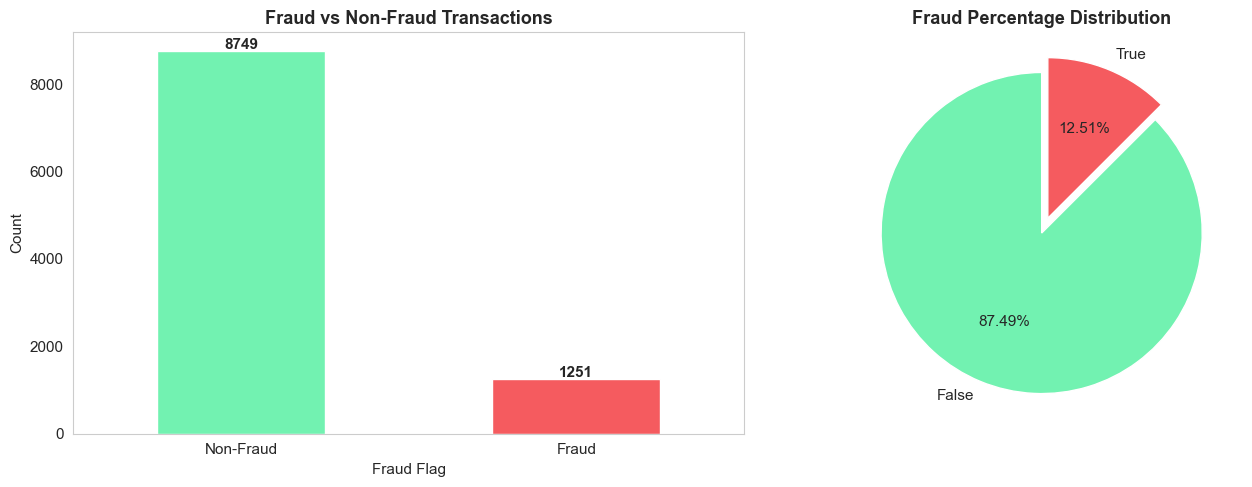

In [16]:
# Display the bar and pie chart of fraud and non-fraud transactions in banking transactions

# Create side-by-side subplots for fraud analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart (Fraud vs Non-Fraud Counts)
df['fraud_flag'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#72F2B1', '#F55B5F']
)
axes[0].set_title(
    'Fraud vs Non-Fraud Transactions', fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('Fraud Flag')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)
axes[0].grid(False)

# Add count labels on top of the bars
for i, v in enumerate(df['fraud_flag'].value_counts().values):
  axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Pie Chart (Fraud Percentage Distribution)
df['fraud_flag'].value_counts().plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.2f%%',
    colors=['#72F2B1', '#F55B5F'],
    explode=[0, 0.1],
    startangle=90,
)
axes[1].set_title('Fraud Percentage Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

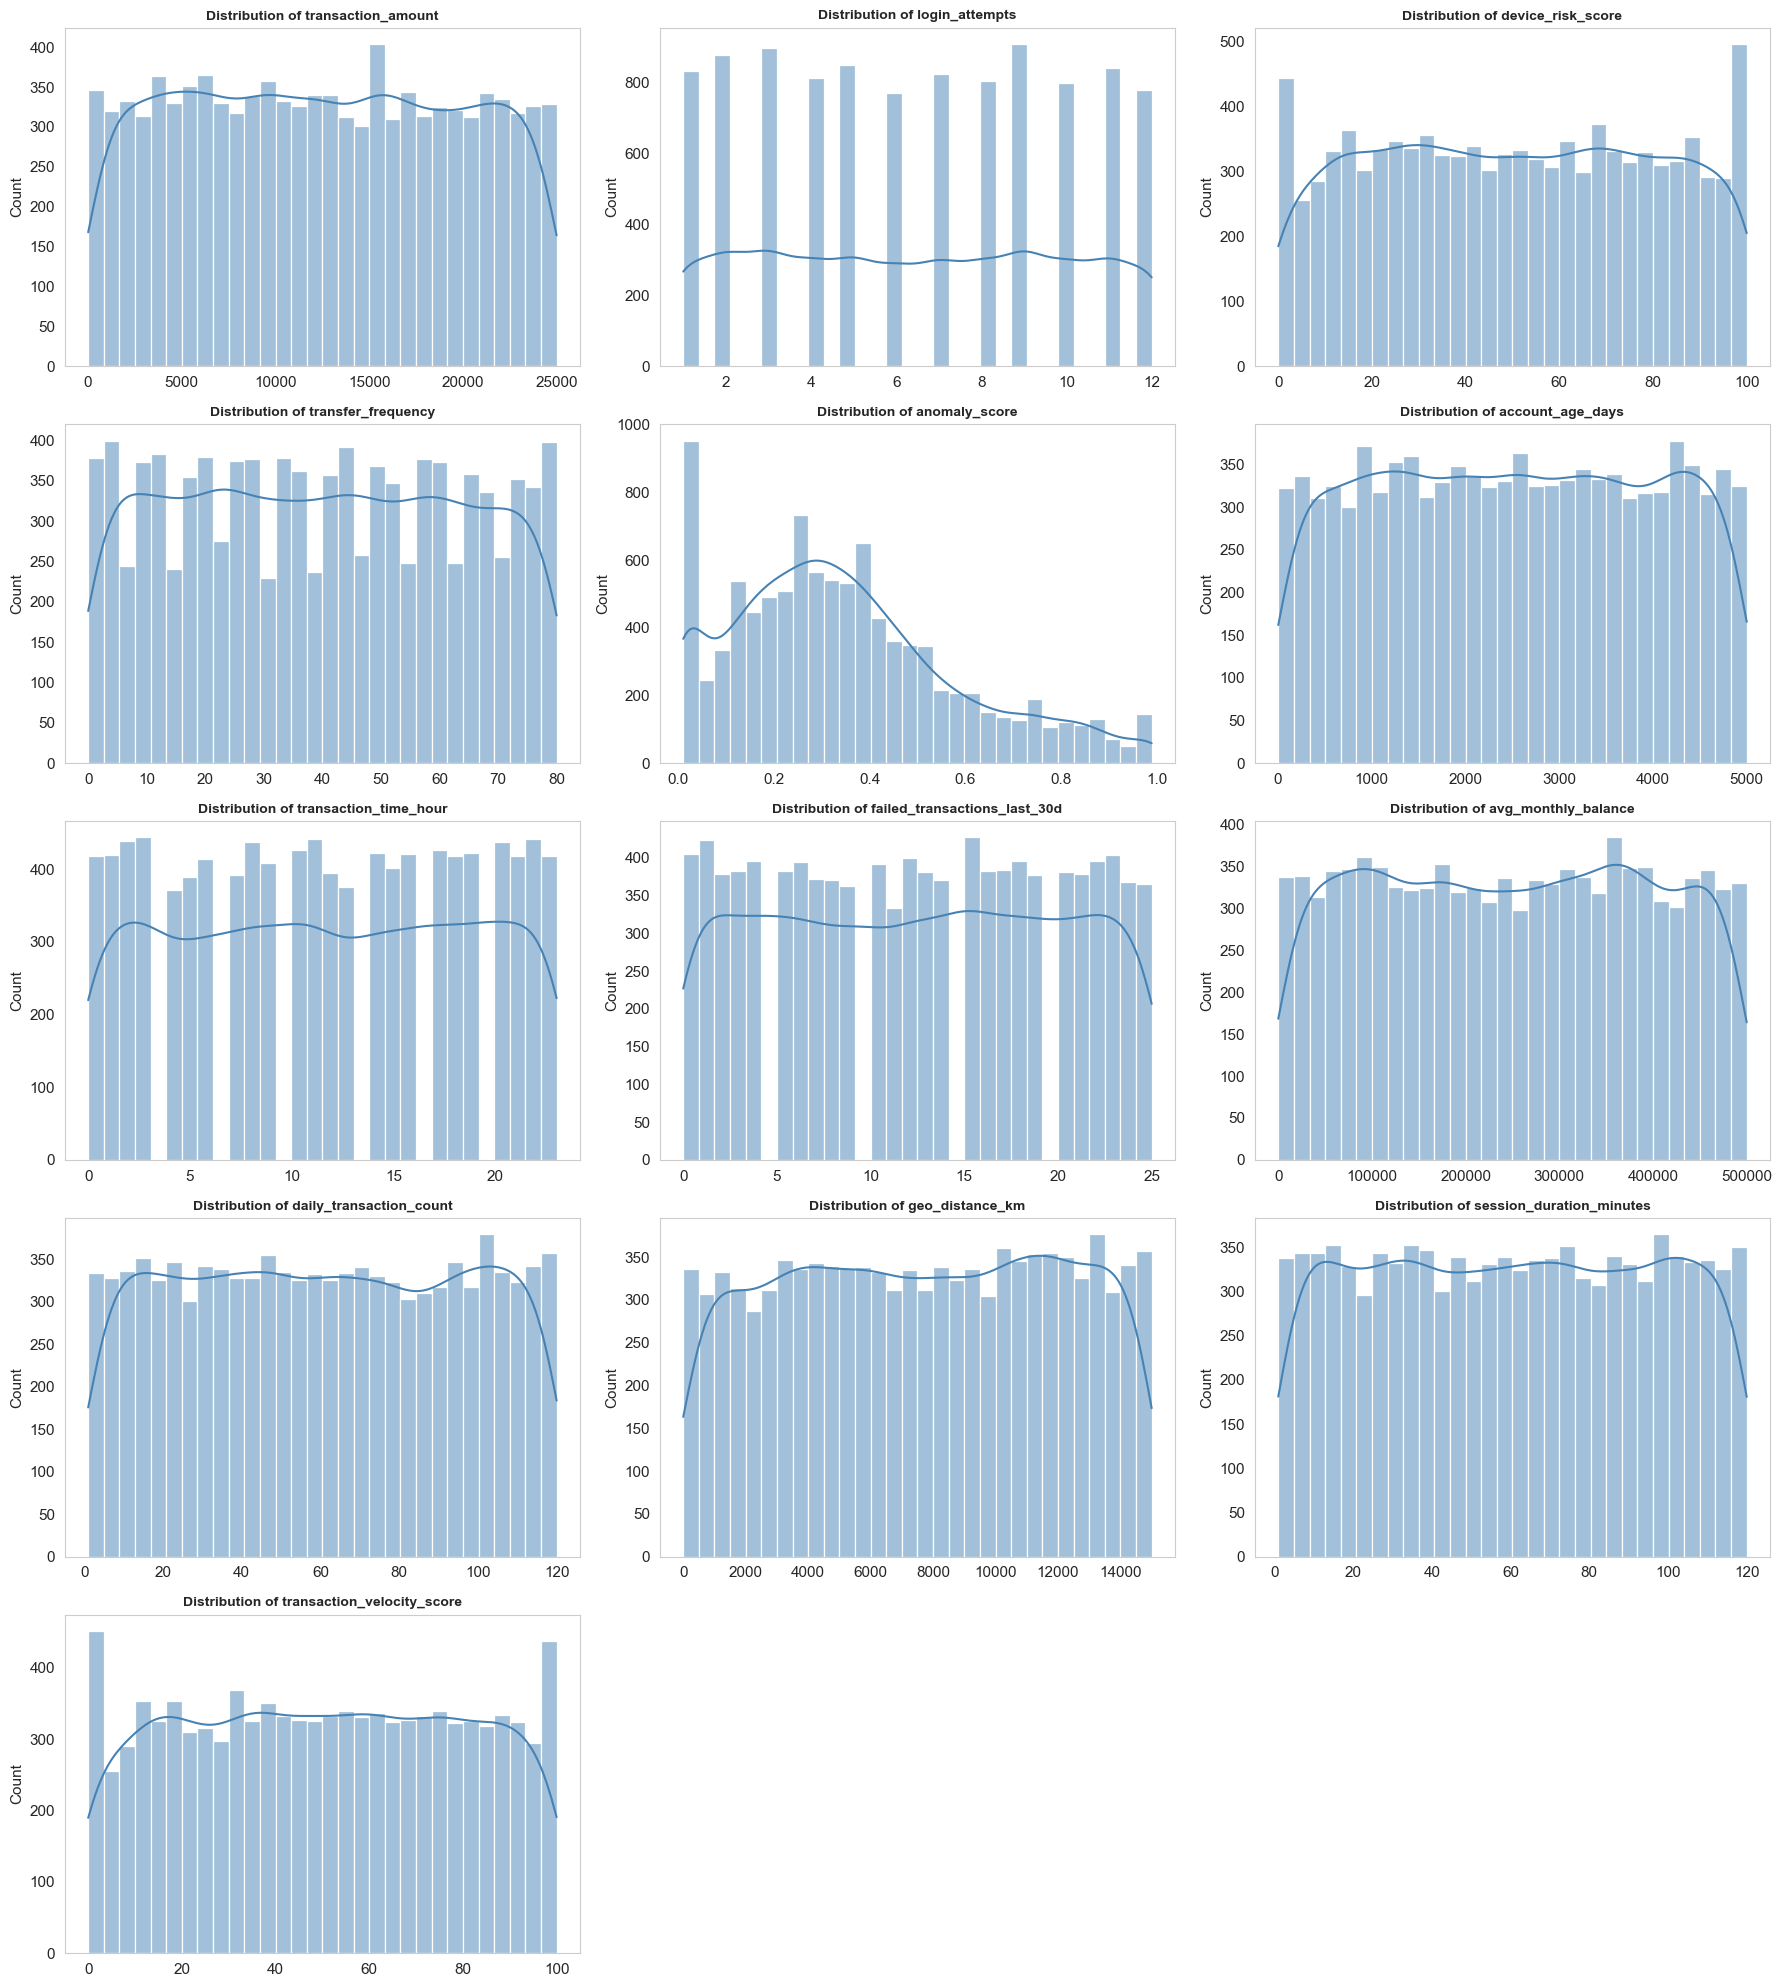

In [17]:
# Display the distributions of all numerical features in a clean 4x4 grid layout

# Plot distribution of all numerical features
numerical_cols = [
    'transaction_amount',
    'login_attempts',
    'device_risk_score',
    'transfer_frequency',
    'anomaly_score',
    'account_age_days',
    'transaction_time_hour',
    'failed_transactions_last_30d',
    'avg_monthly_balance',
    'daily_transaction_count',
    'geo_distance_km',
    'session_duration_minutes',
    'transaction_velocity_score',
]

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
  sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
  axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
  axes[i].set_xlabel('')
  axes[i].grid(False)  

# Remove extra empty subplots
for ax in axes[len(numerical_cols) :]:
  fig.delaxes(ax)

plt.tight_layout()
plt.show()

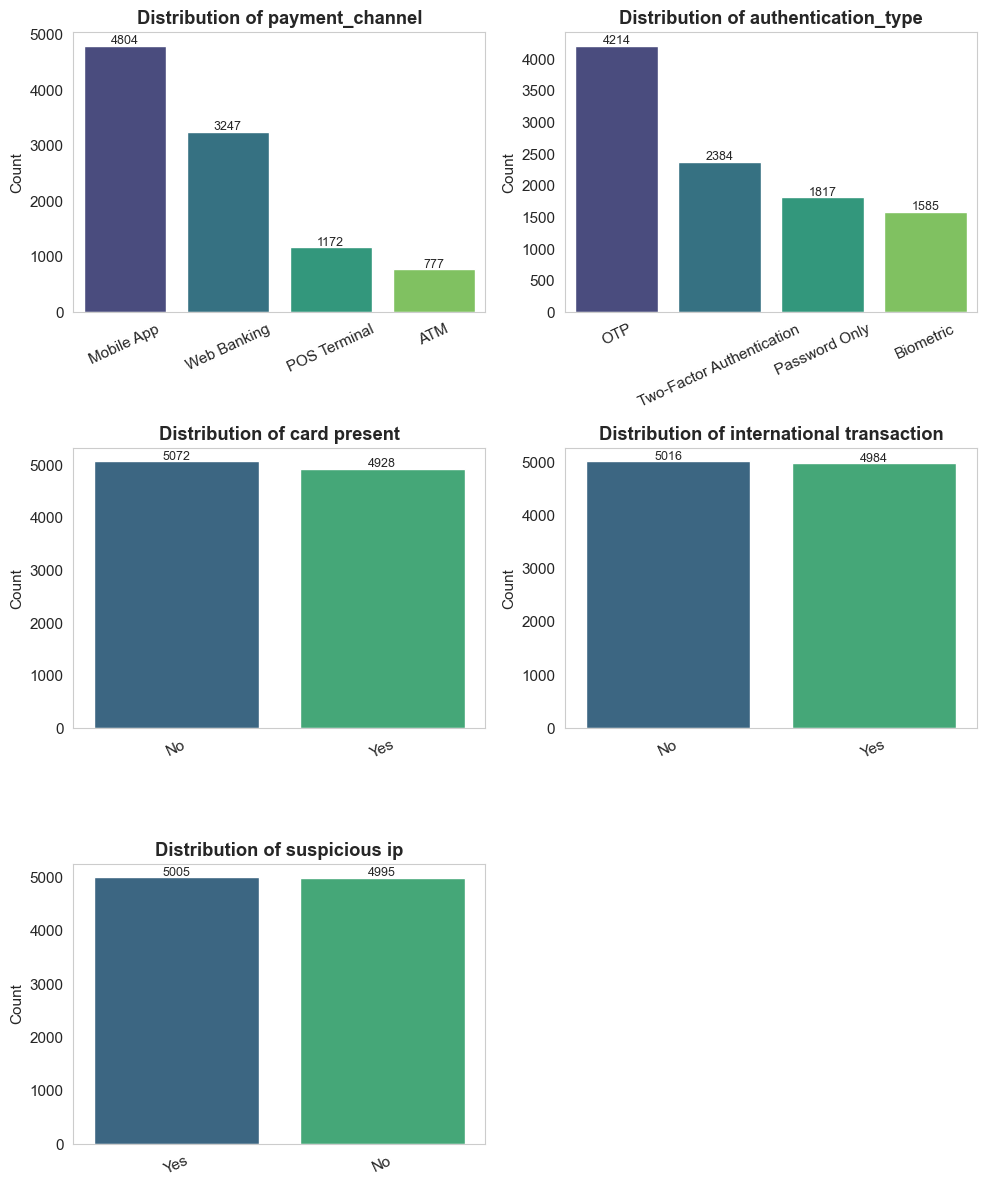

In [18]:
# Display the list of categorical columns to plot
categorical_cols = [
    'payment_channel',
    'authentication_type',
    'card present',
    'international transaction',
    'suspicious ip',
]

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

# Loop through each column and draw a bar plot
for i, col in enumerate(categorical_cols):
  # Get value counts
  counts = df[col].value_counts()

  # Plot bar chart
  sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis')

  # Formatting titles and labels
  axes[i].set_title(f'Distribution of {col}', fontweight='bold')
  axes[i].set_xlabel('')
  axes[i].set_ylabel('Count')

  # Rotate x-labels slightly to prevent overlap
  axes[i].tick_params(axis='x', rotation=25)
  axes[i].grid(False)

  # Add value counts on top of bars
  for j, v in enumerate(counts.values):
    axes[i].text(j, v + 30, str(v), ha='center', fontsize=9)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

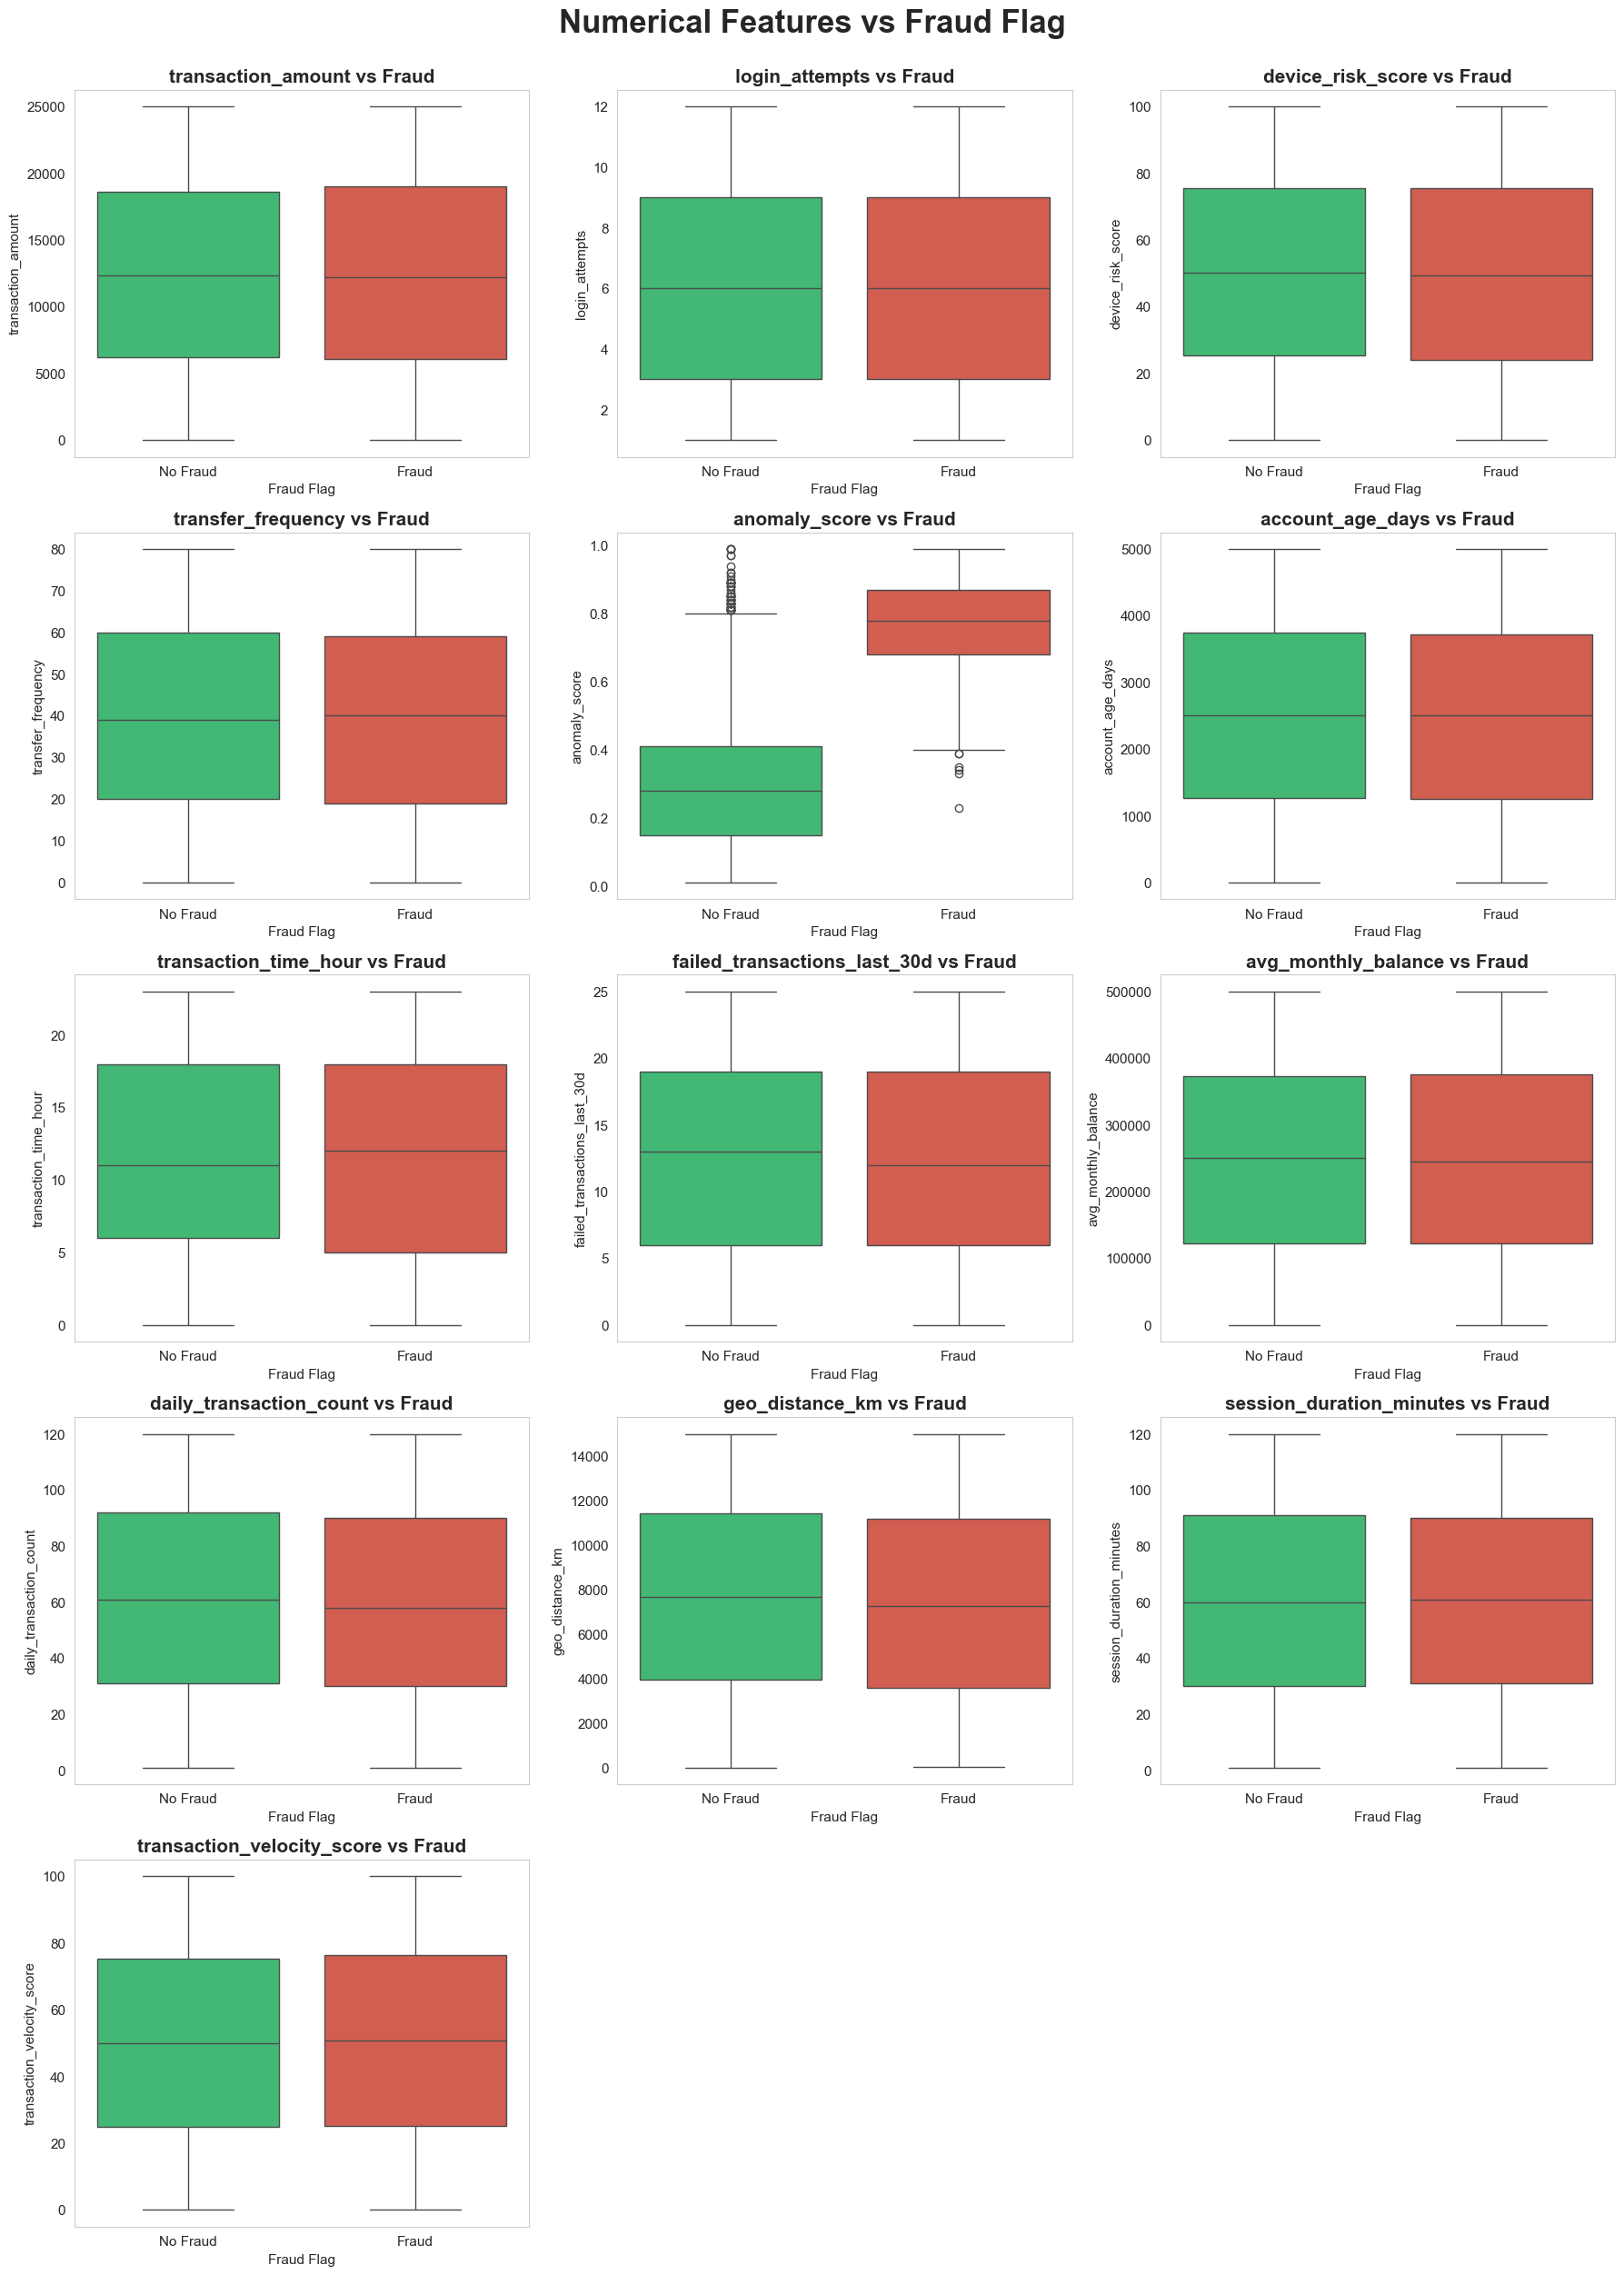

In [19]:
# Display a 5x3 grid of boxplots to visualize and compare numerical features against the fraud flag

# Create a 4x4 grid layout for comparing numerical features with the fraud flag
fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

# Loop through each numerical column and draw a boxplot
for i, col in enumerate(numerical_cols):
  sns.boxplot(
      x='fraud_flag', y=col, data=df, ax=axes[i], palette=['#2ecc71', '#e74c3c']
  )

  # Set titles and axis labels
  axes[i].set_title(f'{col} vs Fraud', fontsize=15, fontweight='bold')
  axes[i].set_xlabel('Fraud Flag')
  axes[i].set_xticklabels(['No Fraud', 'Fraud'])
  axes[i].grid(False)  

# Hide any empty/unused subplots in the grid
for j in range(len(numerical_cols), len(axes)):
  axes[j].set_visible(False)

# Add overall title and display the plot
plt.suptitle(
    'Numerical Features vs Fraud Flag', fontsize=25, fontweight='bold', y=1.00
)
plt.tight_layout()
plt.show()

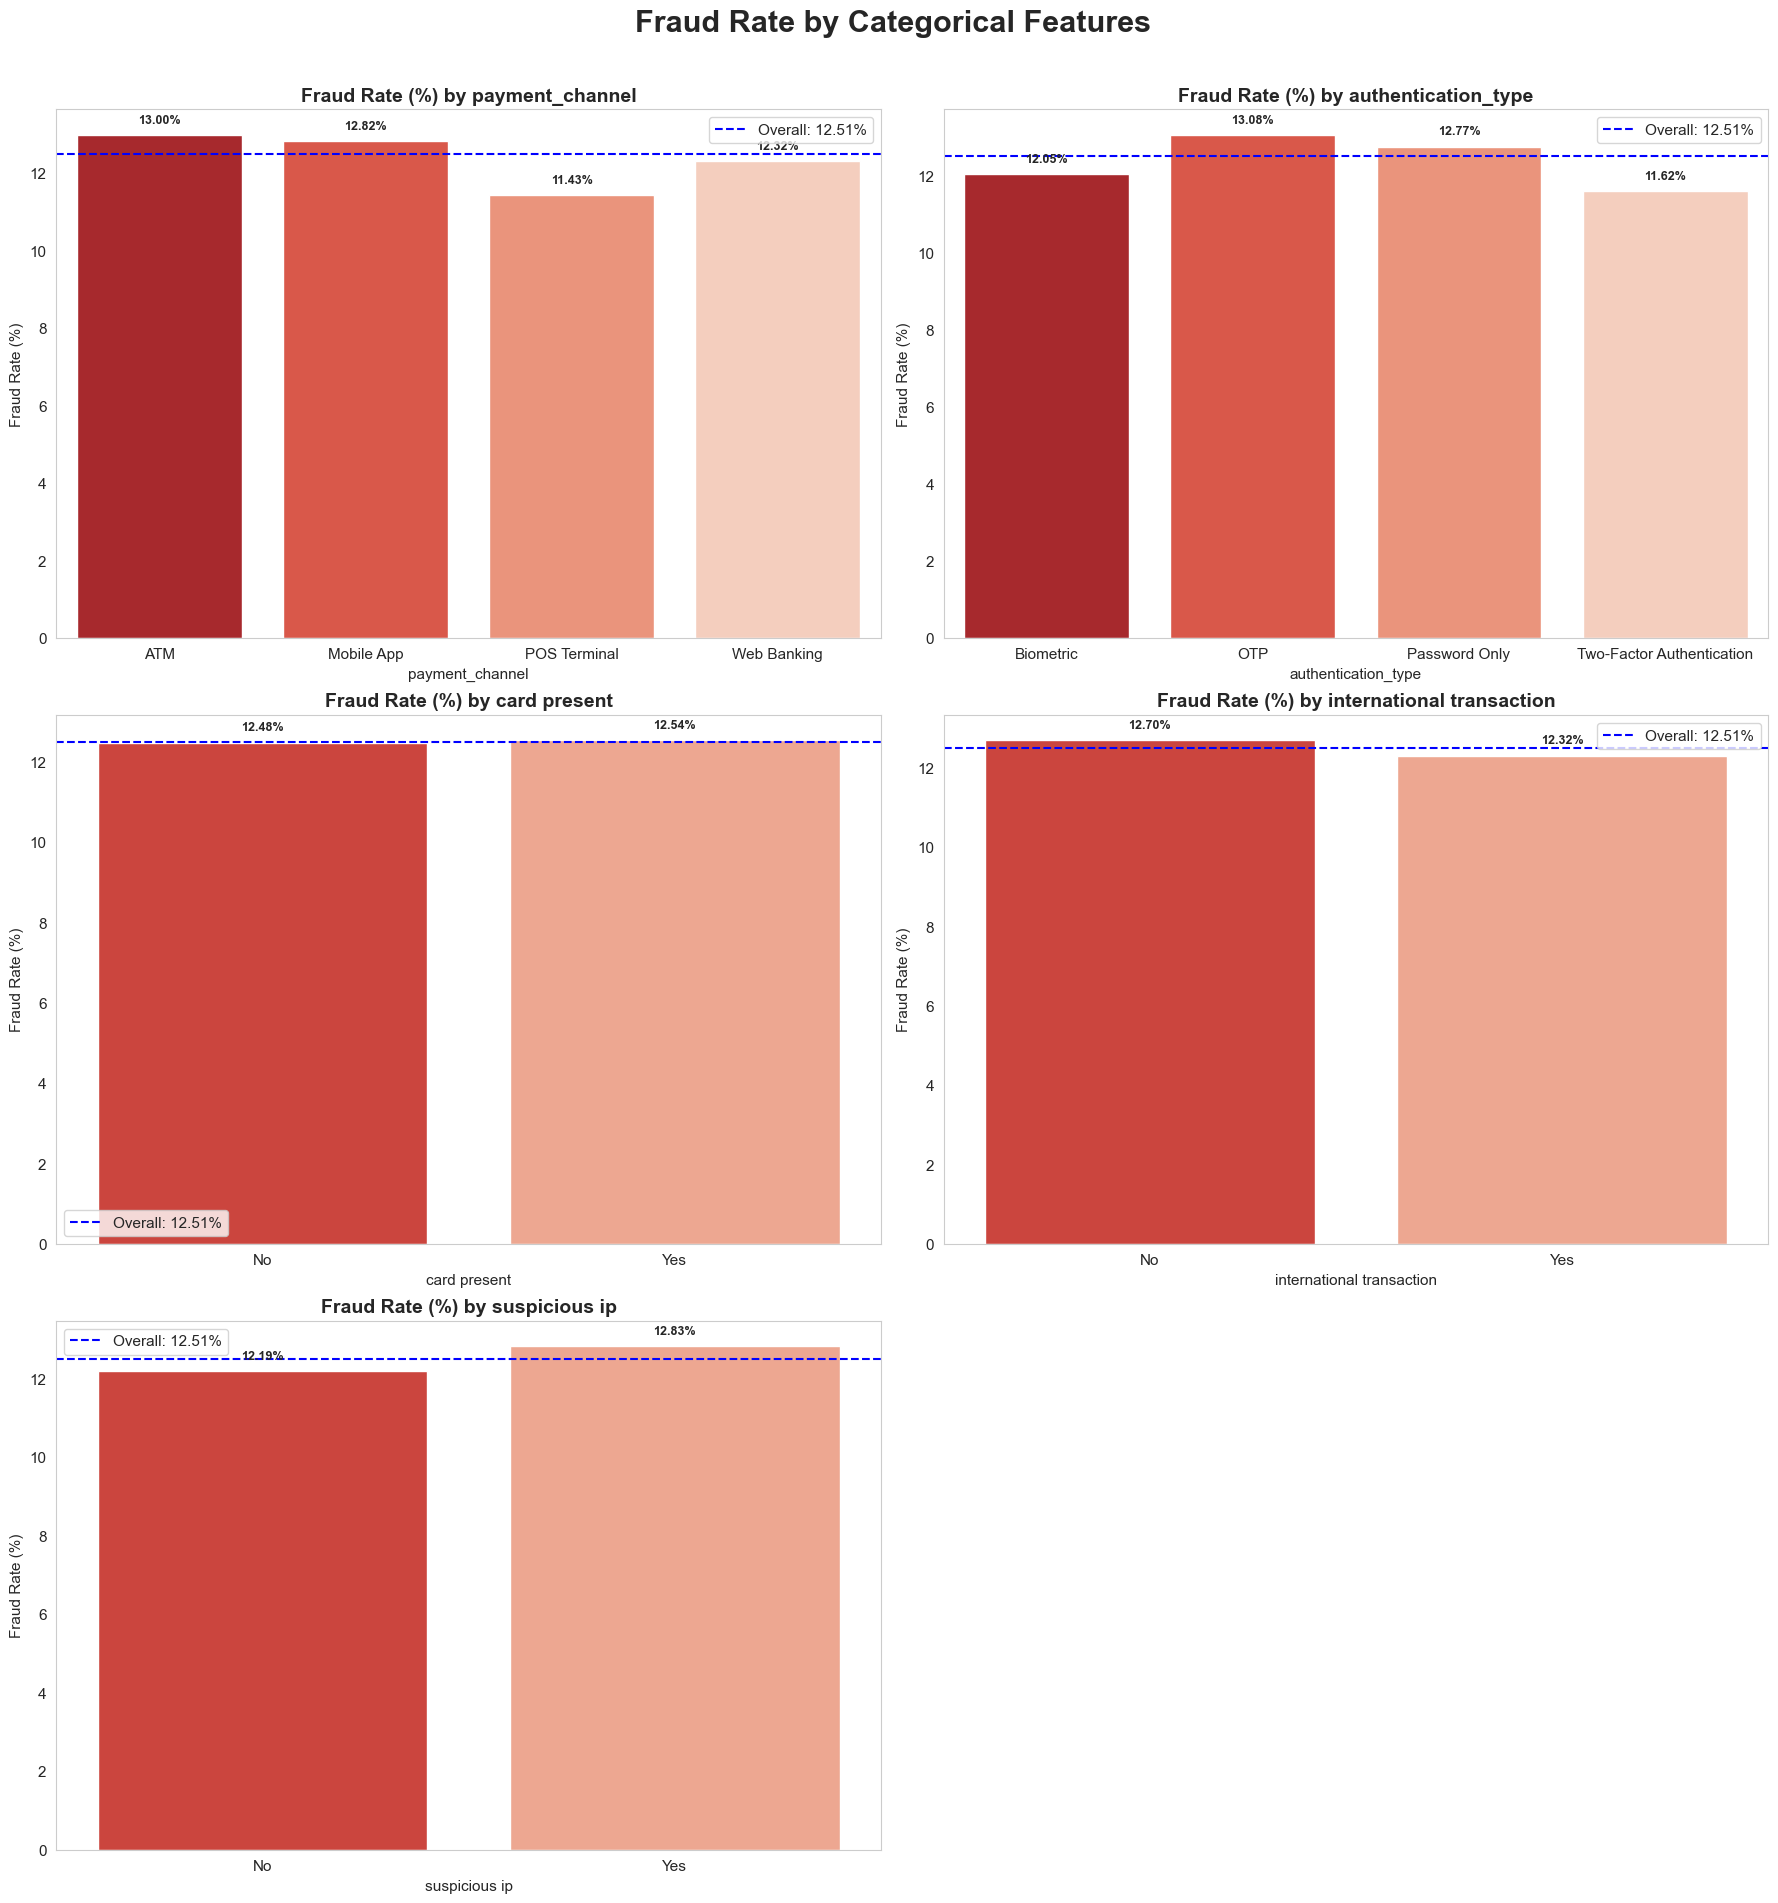

In [20]:
# Display the fraud rate percentage across different categorical features using subplots

# --- Fraud Rate by Categorical Features ---
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
axes = axes.flatten()

# Loop through each categorical column to plot fraud rates
for i, col in enumerate(categorical_cols):
  # Calculate percentage of fraud for each category
  fraud_by_cat = df.groupby(col)['fraud_flag'].mean() * 100

  # Create bar plot
  sns.barplot(
      x=fraud_by_cat.index,
      y=fraud_by_cat.values,
      ax=axes[i],
      palette='Reds_r',
  )

  # Set titles and labels
  axes[i].set_title(f'Fraud Rate (%) by {col}', fontsize=14, fontweight='bold')
  axes[i].set_ylabel('Fraud Rate (%)')
  axes[i].set_xlabel(col)
  axes[i].grid(False)  

  # Add a dashed line for the overall average fraud rate
  axes[i].axhline(
      y=fraud_rate, color='blue', linestyle='--', label=f'Overall: {fraud_rate:.2f}%'
  )
  axes[i].legend()

  # Write the exact percentage value on top of each bar
  for j, v in enumerate(fraud_by_cat.values):
    axes[i].text(j, v + 0.3, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# Hide the last unused subplot in the grid
axes[-1].set_visible(False)

# Add main title with proper spacing to fix the overlap
plt.suptitle(
    'Fraud Rate by Categorical Features', fontsize=22, fontweight='bold', y=0.95
)

# Push the subplots down slightly to create space below the main title
plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

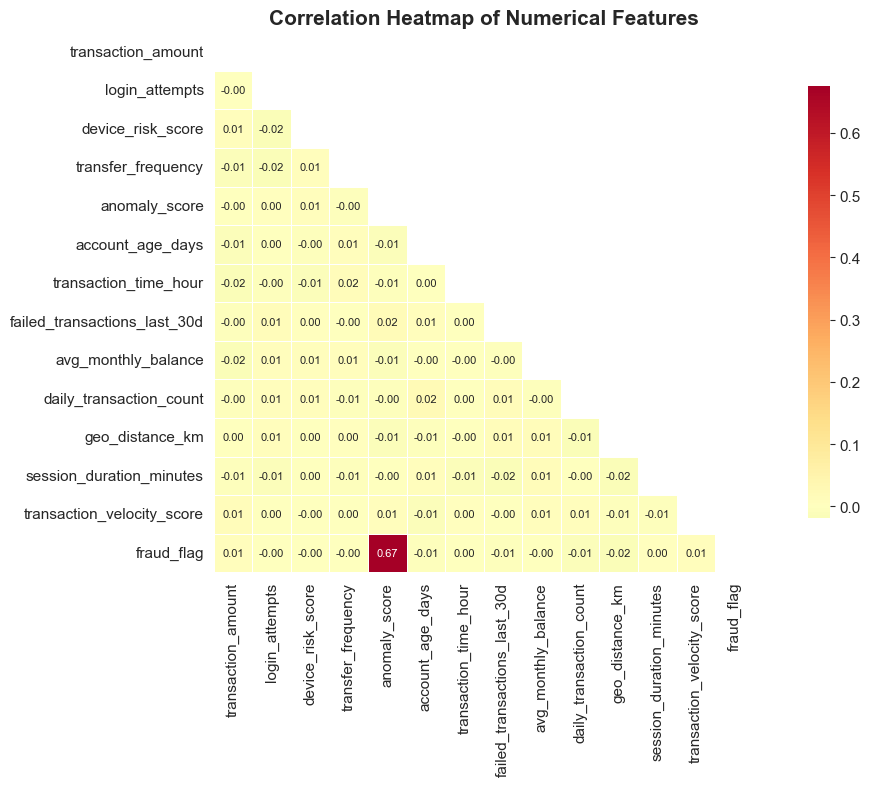

In [21]:
# Display a correlation heatmap to check relationships between numerical features and fraud

plt.figure(figsize=(12, 8))
corr_cols = numerical_cols + ['fraud_flag']
corr_matrix = df[corr_cols].corr()

# Create a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set background style without gridlines for a cleaner look
sns.set_style("white")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8},
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

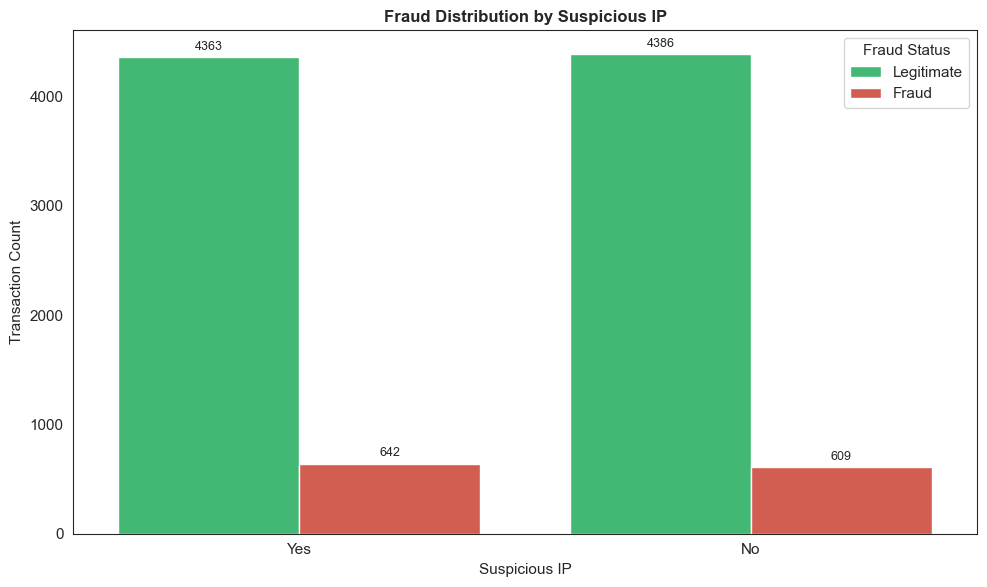

In [22]:
# Display how many frauds happen when the IP address is flagged as suspicious

plt.figure(figsize=(10, 6))

# Plot count of transactions based on suspicious IP and fraud status
ax = sns.countplot(
    x='suspicious ip',
    hue='fraud_flag',
    data=df,
    palette=['#2ecc71', '#e74c3c'],
)

# Loop through each bar to add the exact count label on top
for p in ax.patches:
  height = p.get_height()
  if height > 0:  # Only label bars that have data
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),  # Shift slightly above the bar
        textcoords='offset points',
    )

# Add titles and labels
plt.title('Fraud Distribution by Suspicious IP', fontsize=12, fontweight='bold')
plt.xlabel('Suspicious IP')
plt.ylabel('Transaction Count')

# Update legend names for clarity
plt.legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])

# Remove background gridlines for a cleaner look
ax.grid(False)

plt.tight_layout()
plt.show()

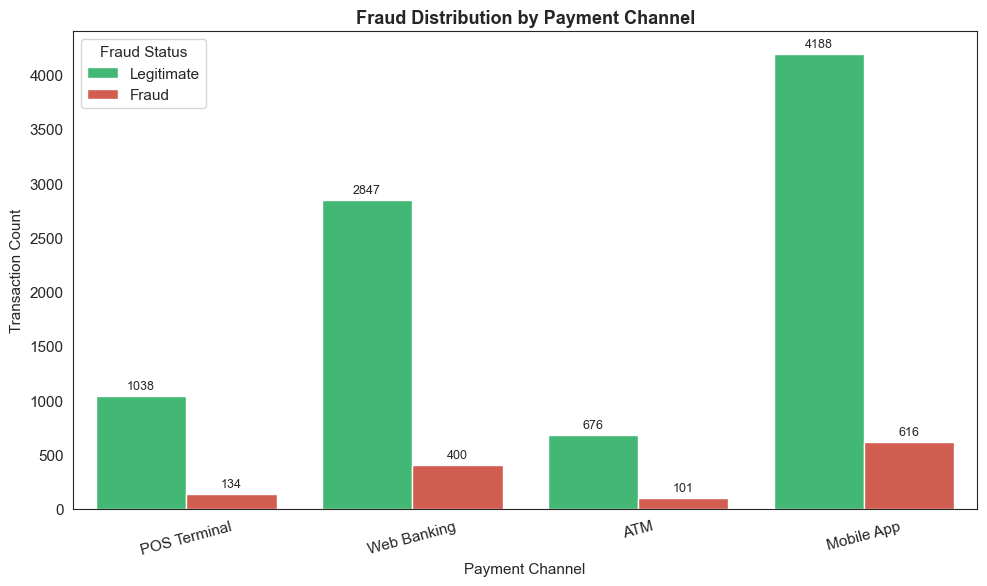

In [23]:
# Display how fraud is distributed across different payment channels

plt.figure(figsize=(10, 6))

# Plot countplot for payment channels grouped by fraud status
ax = sns.countplot(
    x='payment_channel',
    hue='fraud_flag',
    data=df,
    palette=['#2ecc71', '#e74c3c'],
)

# Loop through the bars to add numerical counts on top of each bar
for p in ax.patches:
  height = p.get_height()
  if (
      height > 0
  ):  # Only add labels to bars that actually have data/height
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),  # Offset slightly above the bar
        textcoords='offset points',
    )

# Set titles and axis labels
plt.title('Fraud Distribution by Payment Channel', fontsize=13, fontweight='bold')
plt.xlabel('Payment Channel')
plt.ylabel('Transaction Count')

# Make legend labels clear
plt.legend(title='Fraud Status', labels=['Legitimate', 'Fraud'])

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=15)

# Remove background gridlines for a cleaner look
ax.grid(False)

plt.tight_layout()
plt.show()

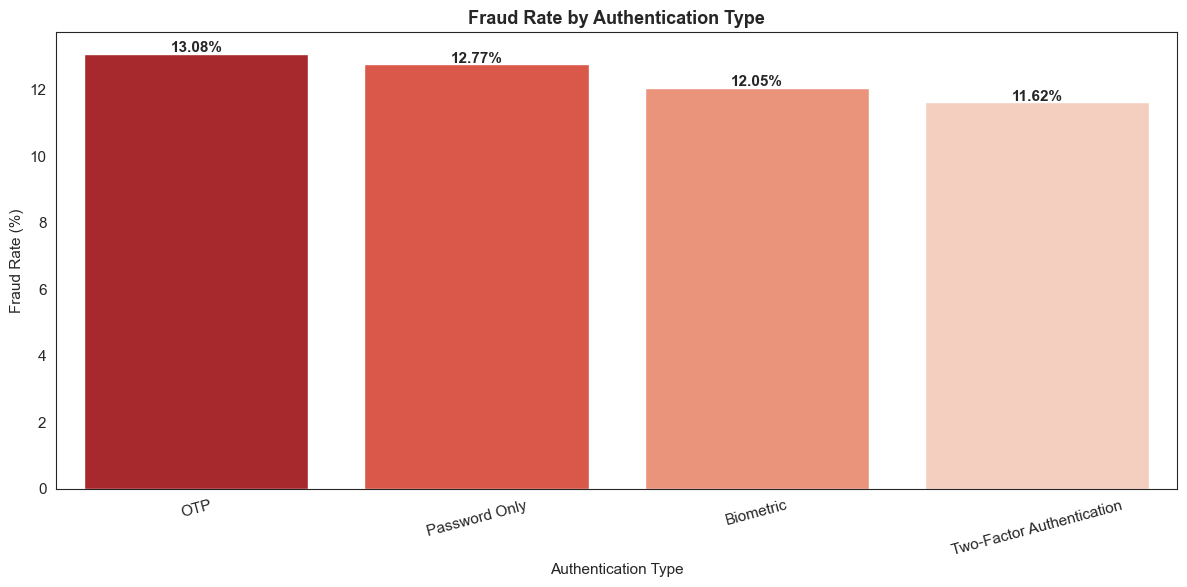

In [24]:
# Analyze and visualize the fraud rate across different authentication types

# Step 1: Group by authentication type and calculate mean and count
auth_fraud = df.groupby('authentication_type')['fraud_flag'].agg(
    ['mean', 'count']
)

# Step 2: Convert the mean to a percentage and sort from highest to lowest
auth_fraud['fraud_rate'] = auth_fraud['mean'] * 100
auth_fraud = auth_fraud.sort_values(by='fraud_rate', ascending=False)

# Step 3: Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=auth_fraud.index, y=auth_fraud['fraud_rate'], palette='Reds_r')

# Step 4: Format chart labels and title
plt.title('Fraud Rate by Authentication Type', fontsize=13, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Authentication Type')
plt.xticks(rotation=15)

# Step 5: Add percentage values on top of each bar
for i, v in enumerate(auth_fraud['fraud_rate'].values):
  plt.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# Perform t-test to check if numerical features are different for fraud vs non-fraud

fraud = df[df['fraud_flag'] == True]
non_fraud = df[df['fraud_flag'] == False]

print("\n🔬 T-Test: Comparing Means of Fraud vs Non-Fraud Groups")
print("-" * 97)
print(
    f"{'Feature':<35} {'Fraud Mean':>12} {'Non-Fraud Mean':>18}"
    f" {'P-Value':>12} {'Significant':>16}"
)
print("-" * 97)

test_results = []

for col in numerical_cols:
  t_stat, p_val = stats.ttest_ind(fraud[col], non_fraud[col], equal_var=False)

  # Check if result is statistically significant
  if p_val < 0.05:
    sig = "✅ YES"
  else:
    sig = "❌ NO"

  test_results.append({
      "Feature": col,
      "Fraud_Mean": fraud[col].mean(),
      "NonFraud_Mean": non_fraud[col].mean(),
      "P_Value": p_val,
      "Significant": sig,
  })

  print(
      f"{col:<35} {fraud[col].mean():>12.2f} {non_fraud[col].mean():>15.2f}"
      f" {p_val:>15.4f} {sig:>12}"
  )

test_df = pd.DataFrame(test_results)


🔬 T-Test: Comparing Means of Fraud vs Non-Fraud Groups
-------------------------------------------------------------------------------------------------
Feature                               Fraud Mean     Non-Fraud Mean      P-Value      Significant
-------------------------------------------------------------------------------------------------
transaction_amount                      12515.91        12398.00          0.5936         ❌ NO
login_attempts                              6.43            6.44          0.9232         ❌ NO
device_risk_score                          50.16           50.27          0.8993         ❌ NO
transfer_frequency                         39.49           39.67          0.7935         ❌ NO
anomaly_score                               0.77            0.29          0.0000        ✅ YES
account_age_days                         2490.66         2513.04          0.6050         ❌ NO
transaction_time_hour                      11.56           11.55          0.9811      

In [26]:
# KEY BUSINESS INSIGHTS

print("\n" + "=" * 23)
print("KEY BUSINESS INSIGHTS")
print("=" * 23)

print(f"""
📌 Anomaly score is the strongest fraud indicator :- 
        → Fraud transactions average 0.77 vs 0.29 for non-fraud (p-value ≈ 0.0000, statistically significant).

📌 Dataset is heavily imbalanced :- 
        → Only 12.51% of transactions are fraud (1,251 out of 10,000), which is much higher than real-world rates (0.01%–0.2%).

📌 Suspicious IPs show higher fraud rate :- 
        → 13.10% fraud rate for suspicious IPs vs 11.93% for normal IPs.

📌 All other numerical features are NOT significant :- 
        → Transaction_amount, login_attempts, device_risk_score, geo_distance_km, etc., all have p-values > 0.05.

📌 Fraud exists across all payment channels :- 
        → Mobile App, Web Banking, POS Terminal, and ATM all show similar fraud patterns.

📌 No authentication type is safe :- 
        → Fraud occurs with Password Only, OTP, Two-Factor Authentication, and Biometric alike.

📌 Correlation heatmap confirms weak relationships :- 
        → No numerical feature shows strong correlation with fraud_flag except anomaly_score.

📌 Weak/random features suggest synthetic data :- 
        → The lack of signal in most features hints the dataset may be artificially generated or pre-processed.

""")



KEY BUSINESS INSIGHTS

📌 Anomaly score is the strongest fraud indicator :- 
        → Fraud transactions average 0.77 vs 0.29 for non-fraud (p-value ≈ 0.0000, statistically significant).

📌 Dataset is heavily imbalanced :- 
        → Only 12.51% of transactions are fraud (1,251 out of 10,000), which is much higher than real-world rates (0.01%–0.2%).

📌 Suspicious IPs show higher fraud rate :- 
        → 13.10% fraud rate for suspicious IPs vs 11.93% for normal IPs.

📌 All other numerical features are NOT significant :- 
        → Transaction_amount, login_attempts, device_risk_score, geo_distance_km, etc., all have p-values > 0.05.

📌 Fraud exists across all payment channels :- 
        → Mobile App, Web Banking, POS Terminal, and ATM all show similar fraud patterns.

📌 No authentication type is safe :- 
        → Fraud occurs with Password Only, OTP, Two-Factor Authentication, and Biometric alike.

📌 Correlation heatmap confirms weak relationships :- 
        → No numerical feature s

In [27]:
# BUSINESS RECOMMENDATIONS

print("\n" + "=" * 48)
print("STRATEGIC RECOMMENDATIONS FOR THE ORGANIZATION")
print("=" * 48)

print("""
🎯 RECOMMENDATION 1: Prioritize anomaly_score in fraud rules
           → Set a threshold (e.g., > 0.6) to auto-flag transactions for manual review.

🎯 RECOMMENDATION 2: Add extra verification for suspicious IPs
           → Require step-up authentication (e.g., OTP + security question) for these transactions.

🎯 RECOMMENDATION 3: Do not rely on single numerical features
           → Avoid building rules around transaction_amount, login_attempts, or geo_distance_km alone.

🎯 RECOMMENDATION 4: Adopt a multi-layered fraud strategy
           → Since fraud is spread across all channels and auth types, focus on behavior-based detection.

🎯 RECOMMENDATION 5: Improve data quality and collection
           → Work with data engineering to add more informative features (e.g., merchant category, time since last transaction).
   
🎯 RECOMMENDATION 6: Investigate the anomaly_score source
           → Understand if it's already an output of an existing model; if yes, analyze its inputs.

🎯 RECOMMENDATION 7: Use SMOTE or class weighting for modeling
           → Address the imbalanced dataset before training any machine learning model.

🎯 RECOMMENDATION 8: Build a dashboard for real-time monitoring
           → Track anomaly_score, suspicious IPs, and fraud rates by channel continuously.
""")


STRATEGIC RECOMMENDATIONS FOR THE ORGANIZATION

🎯 RECOMMENDATION 1: Prioritize anomaly_score in fraud rules
           → Set a threshold (e.g., > 0.6) to auto-flag transactions for manual review.

🎯 RECOMMENDATION 2: Add extra verification for suspicious IPs
           → Require step-up authentication (e.g., OTP + security question) for these transactions.

🎯 RECOMMENDATION 3: Do not rely on single numerical features
           → Avoid building rules around transaction_amount, login_attempts, or geo_distance_km alone.

🎯 RECOMMENDATION 4: Adopt a multi-layered fraud strategy
           → Since fraud is spread across all channels and auth types, focus on behavior-based detection.

🎯 RECOMMENDATION 5: Improve data quality and collection
           → Work with data engineering to add more informative features (e.g., merchant category, time since last transaction).

🎯 RECOMMENDATION 6: Investigate the anomaly_score source
           → Understand if it's already an output of an existing mo

EXECUTIVE SUMMARY DASHBOARD


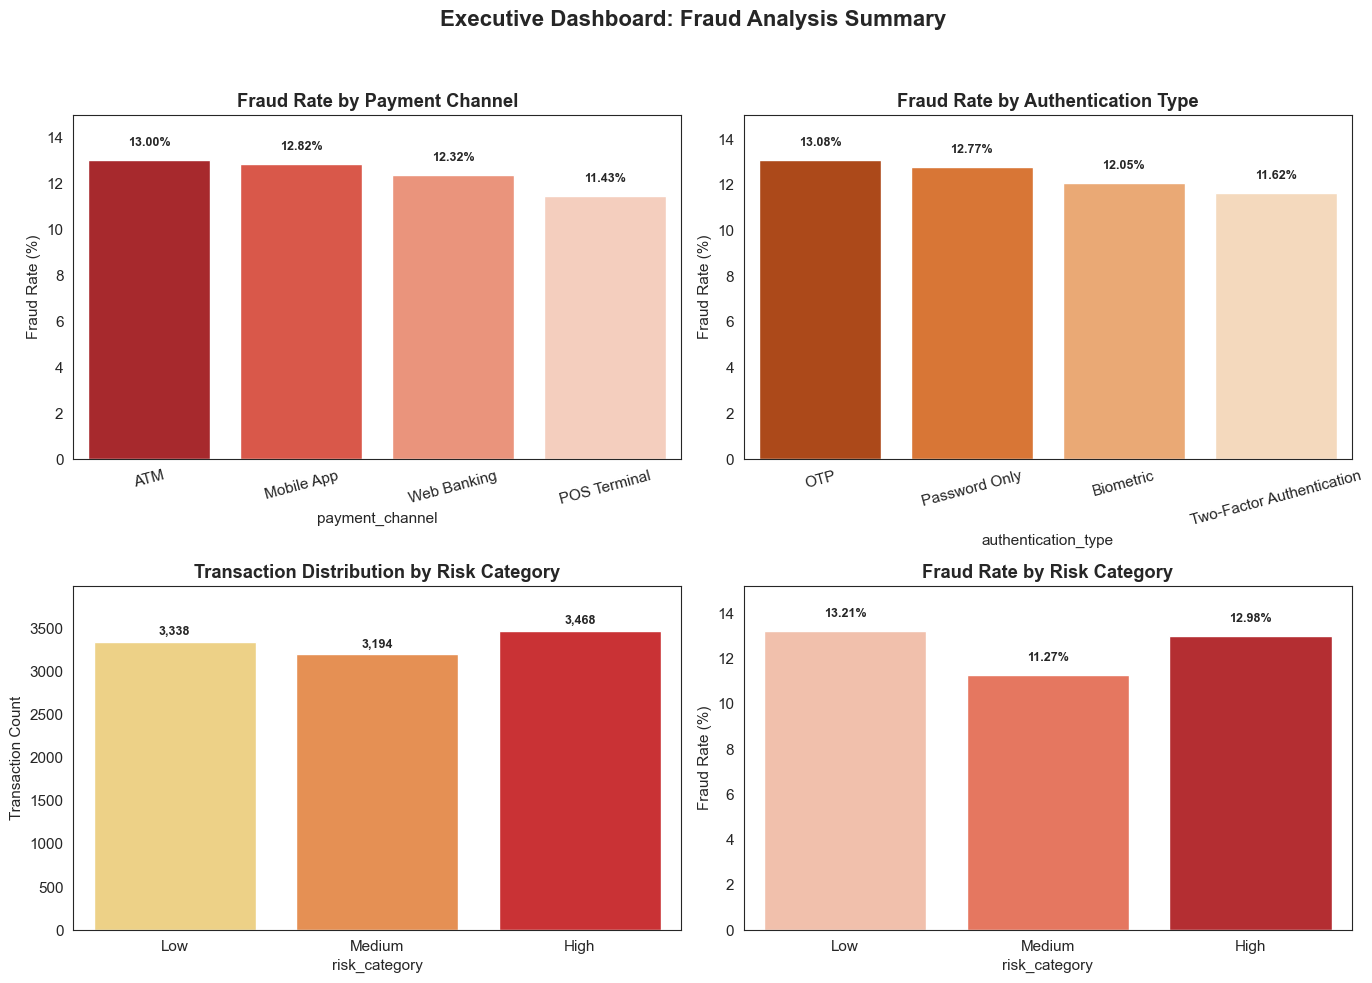

In [42]:
# Generate an executive summary dashboard showing fraud metrics and transaction distributions across categories

print("=" * 40)
print("EXECUTIVE SUMMARY DASHBOARD")
print("=" * 40)

# Step 1: Create the 'risk_category' column if it is missing
if 'risk_category' not in df.columns:
    df['risk_category'] = pd.cut(
        df['device_risk_score'],
        bins=[-1, 33, 66, 100],
        labels=['Low', 'Medium', 'High']
    )

# Step 2: Set up the 2x2 dashboard canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Chart 1: Fraud Rate by Payment Channel ---
payment_fraud = df.groupby('payment_channel', observed=False)['fraud_flag'].mean().sort_values(ascending=False) * 100

sns.barplot(
    x=payment_fraud.index, 
    y=payment_fraud.values, 
    ax=axes[0, 0], 
    palette='Reds_r', 
    hue=payment_fraud.index, 
    legend=False
)
axes[0, 0].set_title('Fraud Rate by Payment Channel', fontweight='bold')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].set_ylim(0, payment_fraud.values.max() * 1.15) # Add headroom for labels

for index, value in enumerate(payment_fraud.values):
    axes[0, 0].text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)


# --- Chart 2: Fraud Rate by Authentication Type ---
auth_fraud = df.groupby('authentication_type', observed=False)['fraud_flag'].mean().sort_values(ascending=False) * 100

sns.barplot(
    x=auth_fraud.index, 
    y=auth_fraud.values, 
    ax=axes[0, 1], 
    palette='Oranges_r', 
    hue=auth_fraud.index, 
    legend=False
)
axes[0, 1].set_title('Fraud Rate by Authentication Type', fontweight='bold')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].set_ylim(0, auth_fraud.values.max() * 1.15)

for index, value in enumerate(auth_fraud.values):
    axes[0, 1].text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)


# --- Chart 3: Transaction Count by Risk Category ---
count_plot = sns.countplot(
    x='risk_category', 
    data=df, 
    ax=axes[1, 0], 
    palette='YlOrRd', 
    hue='risk_category', 
    legend=False
)
axes[1, 0].set_title('Transaction Distribution by Risk Category', fontweight='bold')
axes[1, 0].set_ylabel('Transaction Count')

max_transactions = df['risk_category'].value_counts().max()
axes[1, 0].set_ylim(0, max_transactions * 1.15)

for p in count_plot.patches:
    bar_height = p.get_height()
    if bar_height > 0:
        count_plot.annotate(
            f'{int(bar_height):,}',
            (p.get_x() + p.get_width() / 2., bar_height),
            ha='center', va='bottom',
            fontweight='bold', fontsize=9,
            xytext=(0, 3), textcoords='offset points'
        )


# --- Chart 4: Fraud Rate by Risk Category ---
risk_fraud = df.groupby('risk_category', observed=False)['fraud_flag'].mean() * 100

sns.barplot(
    x=risk_fraud.index, 
    y=risk_fraud.values, 
    ax=axes[1, 1], 
    palette='Reds', 
    hue=risk_fraud.index, 
    legend=False
)
axes[1, 1].set_title('Fraud Rate by Risk Category', fontweight='bold')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_ylim(0, risk_fraud.values.max() * 1.15)

for index, value in enumerate(risk_fraud.values):
    axes[1, 1].text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)


# Step 3: Final layout cleanup
plt.suptitle('Executive Dashboard: Fraud Analysis Summary', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Step 4: Render the plot on screen
plt.show()
